# TD(0) with Q-learning

100%|██████████| 150000/150000 [03:11<00:00, 784.67it/s]


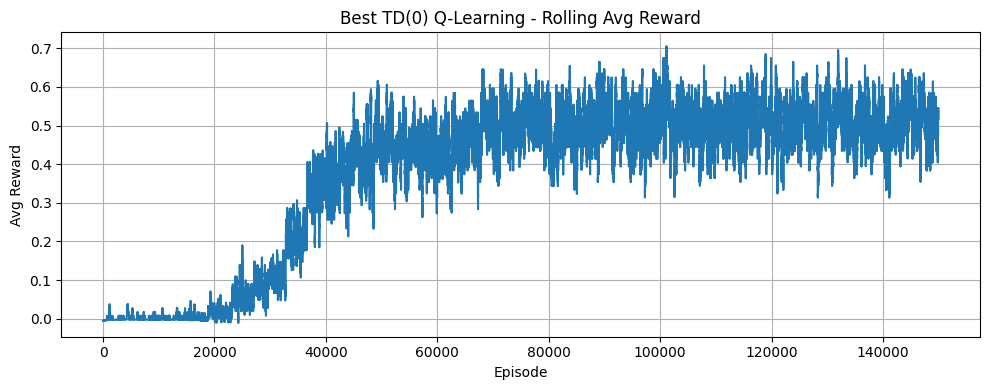

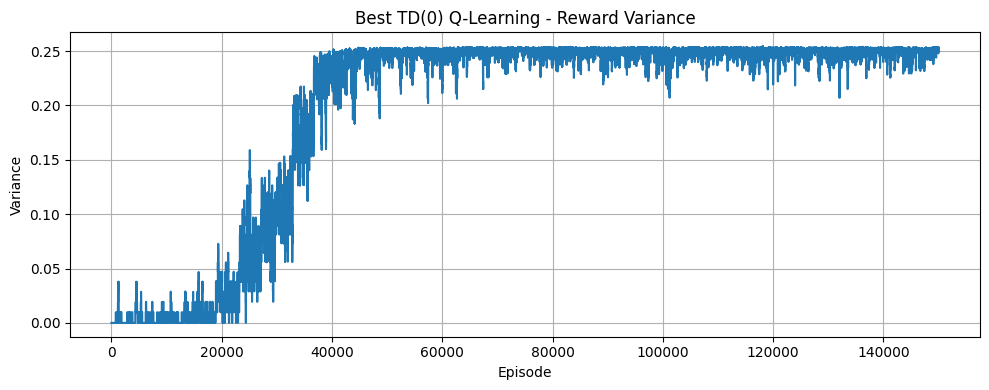


📊 Final Metrics Summary:
🎯 Final Avg Reward           : 0.5449
🌟 Best Avg Reward            : 0.7056
🏁 Goals Reached              : 58254
⚡ Sample Efficiency (ep)     : 68078
📈 Convergence Rate (ep)      : 107
⏱️  Compute Time (sec)        : 191.16


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import trange
import time

# Environment setup
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)
env.reset(seed=42)
np.random.seed(42)

def epsilon_greedy(Q, state, nA, epsilon):
    return np.random.choice(nA) if np.random.rand() < epsilon else np.argmax(Q[state])

def best_td0_q_learning(env, num_episodes=150000, alpha=0.05, gamma=0.995):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards = []
    goals = 0
    start = time.time()

    for ep in trange(num_episodes):
        epsilon = max(0.01, 0.85 * (0.997 ** ep))
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if done and reward == 1.0:
                goals += 1
            if not done or reward == 0:
                reward = -0.0002

            best_next = np.argmax(Q[next_state])
            td_target = reward + gamma * Q[next_state][best_next]
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    elapsed = time.time() - start
    return Q, rewards, goals, elapsed

# Run agent
Q, rewards, goals, time_taken = best_td0_q_learning(env)

# Rolling avg & variance
window = 100
rolling_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
variance = [np.var(rewards[max(0, i-window):i+1]) for i in range(len(rewards))]

# Plot avg reward
plt.figure(figsize=(10, 4))
plt.plot(rolling_avg)
plt.title("Best TD(0) Q-Learning - Rolling Avg Reward")
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot variance
plt.figure(figsize=(10, 4))
plt.plot(variance)
plt.title("Best TD(0) Q-Learning - Reward Variance")
plt.xlabel("Episode")
plt.ylabel("Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

# Metrics
best_avg = np.max(rolling_avg)
sample_eff = next((i for i, val in enumerate(rolling_avg) if val >= 0.9 * best_avg), None)
convergence = next((i for i in range(window, len(rolling_avg)) if np.allclose(
    rolling_avg[i-window:i], rolling_avg[i], rtol=0.05)), None)

# Final Summary
print("\n📊 Final Metrics Summary:")
print(f"🎯 Final Avg Reward           : {round(rolling_avg[-1], 4)}")
print(f"🌟 Best Avg Reward            : {round(best_avg, 4)}")
print(f"🏁 Goals Reached              : {goals}")
print(f"⚡ Sample Efficiency (ep)     : {sample_eff}")
print(f"📈 Convergence Rate (ep)      : {convergence}")
print(f"⏱️  Compute Time (sec)        : {round(time_taken, 2)}")


🔄 Running Combo 1: α=0.01, γ=0.9, ε₀=0.5, decay=0.99, shaping=0
🔄 Running Combo 2: α=0.01, γ=0.9, ε₀=0.5, decay=0.99, shaping=-0.001
🔄 Running Combo 3: α=0.01, γ=0.9, ε₀=0.5, decay=0.995, shaping=0
🔄 Running Combo 4: α=0.01, γ=0.9, ε₀=0.5, decay=0.995, shaping=-0.001
🔄 Running Combo 5: α=0.01, γ=0.9, ε₀=0.9, decay=0.99, shaping=0
🔄 Running Combo 6: α=0.01, γ=0.9, ε₀=0.9, decay=0.99, shaping=-0.001
🔄 Running Combo 7: α=0.01, γ=0.9, ε₀=0.9, decay=0.995, shaping=0
🔄 Running Combo 8: α=0.01, γ=0.9, ε₀=0.9, decay=0.995, shaping=-0.001
🔄 Running Combo 9: α=0.01, γ=0.99, ε₀=0.5, decay=0.99, shaping=0
🔄 Running Combo 10: α=0.01, γ=0.99, ε₀=0.5, decay=0.99, shaping=-0.001
🔄 Running Combo 11: α=0.01, γ=0.99, ε₀=0.5, decay=0.995, shaping=0
🔄 Running Combo 12: α=0.01, γ=0.99, ε₀=0.5, decay=0.995, shaping=-0.001
🔄 Running Combo 13: α=0.01, γ=0.99, ε₀=0.9, decay=0.99, shaping=0
🔄 Running Combo 14: α=0.01, γ=0.99, ε₀=0.9, decay=0.99, shaping=-0.001
🔄 Running Combo 15: α=0.01, γ=0.99, ε₀=0.9, decay=0.

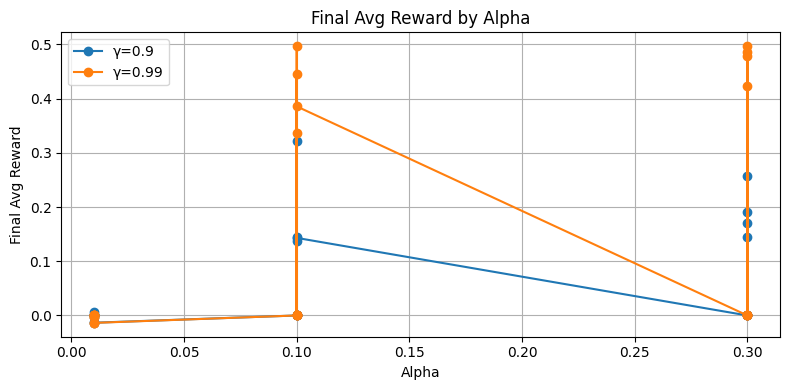

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from collections import defaultdict
from itertools import product

# Environment setup
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)
env.reset(seed=42)
np.random.seed(42)

# Epsilon-greedy policy
def epsilon_greedy(Q, state, nA, epsilon):
    return np.random.choice(nA) if np.random.rand() < epsilon else np.argmax(Q[state])

# TD(0) Q-learning with tunable hyperparameters
def td0_q_learning(env, num_episodes=50000, alpha=0.1, gamma=0.99, epsilon_init=0.9, epsilon_decay=0.995, reward_shaping=-0.001):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards = []
    goal_reached = 0
    start_time = time.time()

    for ep in range(num_episodes):
        epsilon = max(0.01, epsilon_init * (epsilon_decay ** ep))
        state, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if done and reward == 1.0:
                goal_reached += 1
            if not done or reward == 0:
                reward = reward_shaping

            best_next = np.argmax(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * Q[next_state][best_next] - Q[state][action])
            state = next_state
            ep_reward += reward

        rewards.append(ep_reward)

    elapsed_time = time.time() - start_time
    return Q, rewards, goal_reached, elapsed_time

# Grid search function
def grid_search(env, alpha_vals, gamma_vals, epsilon_inits, epsilon_decays, shaping_vals, num_episodes=50000, window=100):
    results = []
    combo_id = 0

    for alpha, gamma, eps_init, eps_decay, shaping in product(alpha_vals, gamma_vals, epsilon_inits, epsilon_decays, shaping_vals):
        combo_id += 1
        print(f"🔄 Running Combo {combo_id}: α={alpha}, γ={gamma}, ε₀={eps_init}, decay={eps_decay}, shaping={shaping}")
        Q, rewards, goals, elapsed = td0_q_learning(
            env,
            num_episodes=num_episodes,
            alpha=alpha,
            gamma=gamma,
            epsilon_init=eps_init,
            epsilon_decay=eps_decay,
            reward_shaping=shaping
        )

        rolling_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        best_avg = np.max(rolling_avg)
        final_avg = rolling_avg[-1]
        convergence = next((i for i in range(window, len(rolling_avg))
                            if np.allclose(rolling_avg[i-window:i], rolling_avg[i], rtol=0.05)), None)
        sample_eff = next((i for i, val in enumerate(rolling_avg)
                           if val >= 0.9 * best_avg), None)

        results.append({
            "alpha": alpha,
            "gamma": gamma,
            "epsilon_init": eps_init,
            "epsilon_decay": eps_decay,
            "reward_shaping": shaping,
            "final_avg_reward": round(final_avg, 4),
            "best_avg_reward": round(best_avg, 4),
            "goals_reached": goals,
            "sample_efficiency": sample_eff,
            "convergence": convergence,
            "compute_time_sec": round(elapsed, 2)
        })

    return pd.DataFrame(results)

# Define hyperparameter grid
alpha_vals = [0.01, 0.1, 0.3]
gamma_vals = [0.9, 0.99]
epsilon_inits = [0.5, 0.9]
epsilon_decays = [0.99, 0.995]
reward_shapings = [0, -0.001]

# Run grid search
results_df = grid_search(
    env,
    alpha_vals=alpha_vals,
    gamma_vals=gamma_vals,
    epsilon_inits=epsilon_inits,
    epsilon_decays=epsilon_decays,
    shaping_vals=reward_shapings,
    num_episodes=50000
)

# Show top 5 configurations
print("\n🏆 Top 5 Configurations by Final Avg Reward:")
print(results_df.sort_values(by="final_avg_reward", ascending=False).head(5))

# Plot alpha vs reward
plt.figure(figsize=(8, 4))
plt.title("Final Avg Reward by Alpha")
plt.grid(True)
plt.xlabel("Alpha")
plt.ylabel("Final Avg Reward")
for gamma in gamma_vals:
    subset = results_df[results_df["gamma"] == gamma]
    plt.plot(subset["alpha"], subset["final_avg_reward"], marker='o', label=f"γ={gamma}")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
## All top configs share gamma = 0.99 and reward_shaping = -0.001.

## alpha = 0.1 and 0.3 both work well — higher α may lead to faster learning but also more variance.

## epsilon_init = 0.5 performed slightly better than 0.9 in top configs, likely due to earlier exploitation.

In [ ]:
## LLM Prompts
1. Train the agent using α=0.1, γ=0.99, ε₀=0.5, decay=0.99, reward_shaping=-0.001 for 100,000 episodes.
2. Give me the plot for aplha vs reward
